# Predictive Analytics

## Objective

Develop a machine learning model capable of predicting Economic Stress Scores using macroeconomic and food security indicators.

### Business Question

Can future economic stress levels be estimated using historical economic and agricultural indicators?

### Modeling Approach

- Data Preparation
- Feature Engineering
- Missing Value Treatment
- Train-Test Split
- Model Training
- Model Evaluation
- Feature Importance Analysis

In [1]:
# =====================================================
# IMPORT LIBRARIES
# =====================================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer

from sklearn.model_selection import train_test_split

from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

pd.set_option('display.max_columns', None)

In [2]:
# =====================================================
# LOAD DATASET
# =====================================================

country_year = pd.read_csv(
    "C:/Users/saksh/Desktop/country-economic-stress-analysis/data/country_year_indicators.csv"
)

country_year.head()

,country_code,country_name,iso3,region,income_group,year,gdp_growth,inflation,unemployment,gdp_per_capita,population,food_production_index,cereal_yield,cereal_production_tonnes,agricultural_land_pct,dietary_energy_supply_adequacy,economic_stress_score,data_completeness_score
0,ABW,Aruba,ABW,Latin America & Caribbean,High income,1960,NaN,NaN,NaN,NaN,54922.0,NaN,NaN,NaN,NaN,NaN,NaN,0
1,ABW,Aruba,ABW,Latin America & Caribbean,High income,1961,NaN,NaN,NaN,NaN,55578.0,NaN,NaN,NaN,11.1111,NaN,NaN,0
2,ABW,Aruba,ABW,Latin America & Caribbean,High income,1962,NaN,NaN,NaN,NaN,56320.0,NaN,NaN,NaN,11.1111,NaN,NaN,0
3,ABW,Aruba,ABW,Latin America & Caribbean,High income,1963,NaN,NaN,NaN,NaN,57002.0,NaN,NaN,NaN,11.1111,NaN,NaN,0
4,ABW,Aruba,ABW,Latin America & Caribbean,High income,1964,NaN,NaN,NaN,NaN,57619.0,NaN,NaN,NaN,11.1111,NaN,NaN,0


In [3]:
# =====================================================
# MODEL FEATURES
# =====================================================

features = [
    'gdp_growth',
    'inflation',
    'unemployment',
    'gdp_per_capita',
    'food_production_index',
    'cereal_yield',
    'agricultural_land_pct',
    'dietary_energy_supply_adequacy'
]

target = 'economic_stress_score'

model_df = country_year[
    features + [target]
].copy()

model_df.head()

,gdp_growth,inflation,unemployment,gdp_per_capita,food_production_index,cereal_yield,agricultural_land_pct,dietary_energy_supply_adequacy,economic_stress_score
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,11.1111,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,11.1111,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,11.1111,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,11.1111,NaN,NaN


In [4]:
# =====================================================
# MEDIAN IMPUTATION
# =====================================================

imputer = SimpleImputer(
    strategy='median'
)

model_df[features] = imputer.fit_transform(
    model_df[features]
)

model_df[target] = model_df[target].fillna(
    model_df[target].median()
)

model_df.isnull().sum()

gdp_growth                        0
inflation                         0
unemployment                      0
gdp_per_capita                    0
food_production_index             0
cereal_yield                      0
agricultural_land_pct             0
dietary_energy_supply_adequacy    0
economic_stress_score             0
dtype: int64

In [5]:
# =====================================================
# FEATURES & TARGET
# =====================================================

X = model_df[features]

y = model_df[target]

In [6]:
# =====================================================
# TRAIN TEST SPLIT
# =====================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(11457, 8)
(2865, 8)


In [8]:
# =====================================================
# RANDOM FOREST MODEL
# =====================================================

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(
    X_train,
    y_train
)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [9]:
# =====================================================
# PREDICTIONS
# =====================================================

y_pred = rf.predict(X_test)

In [10]:
# =====================================================
# MODEL PERFORMANCE
# =====================================================

mae = mean_absolute_error(
    y_test,
    y_pred
)

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred
    )
)

r2 = r2_score(
    y_test,
    y_pred
)

performance = pd.DataFrame({
    'Metric': ['MAE', 'RMSE', 'R² Score'],
    'Value': [mae, rmse, r2]
})

performance

,Metric,Value
0,MAE,3.744052
1,RMSE,5.400336
2,R² Score,0.889821


### Model Performance Findings

The Random Forest model achieved strong predictive performance with an R² Score of 0.89, indicating that approximately 89% of the variation in Economic Stress Score can be explained by the selected economic and food security indicators.

The model achieved a Mean Absolute Error (MAE) of 3.74 and a Root Mean Squared Error (RMSE) of 5.40, demonstrating good predictive accuracy relative to the 0–100 Economic Stress Score scale.

These results suggest that economic stress can be effectively estimated using macroeconomic and food security indicators.

In [11]:
# =====================================================
# FEATURE IMPORTANCE
# =====================================================

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

feature_importance = (
    feature_importance
    .sort_values(
        by='Importance',
        ascending=False
    )
)

feature_importance

,Feature,Importance
0,gdp_growth,0.251832
3,gdp_per_capita,0.202246
1,inflation,0.182985
2,unemployment,0.148760
4,food_production_index,0.094101
5,cereal_yield,0.072932
6,agricultural_land_pct,0.030448
7,dietary_energy_supply_adequacy,0.016695


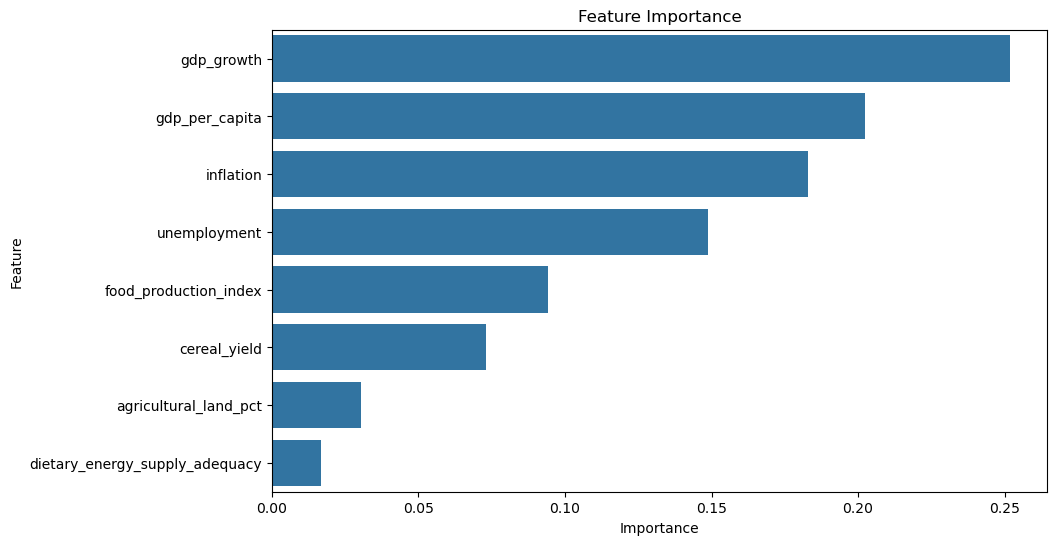

In [12]:
# =====================================================
# FEATURE IMPORTANCE CHART
# =====================================================

plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance,
    x='Importance',
    y='Feature'
)

plt.title(
    'Feature Importance'
)

plt.show()

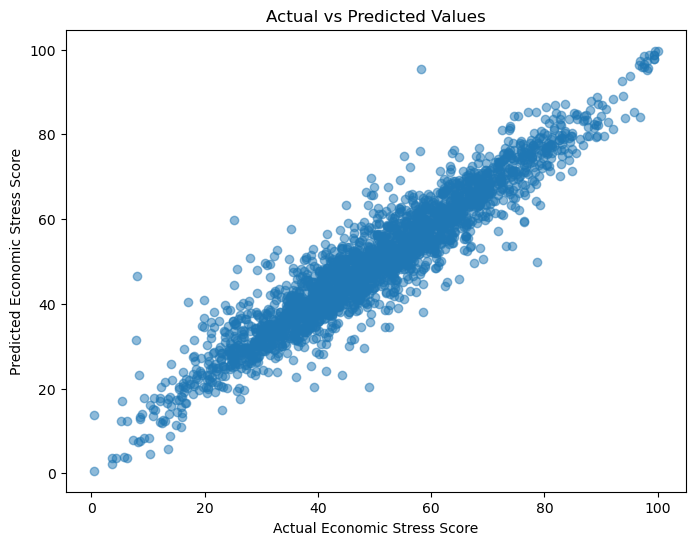

In [13]:
# =====================================================
# ACTUAL VS PREDICTED
# =====================================================

plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.5
)

plt.xlabel(
    'Actual Economic Stress Score'
)

plt.ylabel(
    'Predicted Economic Stress Score'
)

plt.title(
    'Actual vs Predicted Values'
)

plt.show()

### Feature Importance Findings

The Random Forest model identified GDP Growth as the most important predictor of Economic Stress Score, contributing approximately 25.2% of the model's predictive power.

GDP per Capita was the second most influential variable (20.2%), followed by Inflation (18.3%) and Unemployment (14.9%).

Food security indicators also contributed to prediction performance, with Food Production Index (9.4%) and Cereal Yield (7.3%) demonstrating meaningful influence.

#### Top Predictive Variables

1. GDP Growth (25.2%)
2. GDP per Capita (20.2%)
3. Inflation (18.3%)
4. Unemployment (14.9%)
5. Food Production Index (9.4%)

#### Key Insight

The model suggests that economic growth, income levels, inflation, and labor market conditions are the most important factors for estimating economic stress. Food security indicators provide additional explanatory power but are less influential than core macroeconomic variables.

## Predictive Analytics Conclusion

A Random Forest Regression model was developed to estimate Economic Stress Scores using macroeconomic and food security indicators.

The model achieved strong predictive performance with an R² score of 0.89, indicating that the selected indicators explain a substantial proportion of variation in economic stress levels.

Feature importance analysis identified GDP Growth, GDP per Capita, Inflation, and Unemployment as the most influential predictors.

The results demonstrate that economic stress can be effectively estimated using a combination of economic performance, income vulnerability, labor market conditions, and food security measures.

### Limitation

The Economic Stress Score is a derived index that incorporates several of the same indicators used as model inputs. Therefore, the model should be interpreted as demonstrating explanatory relationships rather than providing a pure forecasting framework for future economic stress.